# 🚗 Previsão de Severidade de Acidentes Rodoviários em Santa Catarina (PRF 2020–2025)
## Sprint 2 — MVP Analítico: Pipeline de Pré-processamento, Engenharia de Atributos e Modelagem Baseline

---

### 📌 Contexto de Negócio e Objetivo
As rodovias federais que cortam o estado de Santa Catarina (como a **BR-101**, **BR-282** e **BR-470**) concentram intensos fluxos logísticos e turísticos, registrando milhares de acidentes anualmente. Identificar previamente o grau de severidade de uma ocorrência ou classificar os riscos com base em atributos da via, clima e horário é crucial para:
1. **Otimização da alocação de equipes de resgate** (ambulâncias, suporte aeromédico e viaturas da PRF).
2. **Priorização de investimentos em engenharia de tráfego** em pontos críticos.
3. **Desenvolvimento de alertas preventivos** a condutores em tempo real.

Neste notebook da **Sprint 2**, construímos um pipeline ponta-a-ponta reproduzível que engloba:
- **Tratamento e limpeza de dados** com prevenção explícita de *data leakage* (vazamento de dados).
- **Engenharia de atributos temporais e contextuais** (`eh_fim_de_semana`, `periodo_do_dia`, `mes`, `eh_feriado`).
- **Definição da variável-alvo multiclasse**:
  - **Classe 0**: Acidente sem vítimas
  - **Classe 1**: Acidente com feridos
  - **Classe 2**: Acidente fatal
- **Treinamento e comparação de 3 modelos baseline**:
  - *Random Forest* (`RandomForestClassifier`)
  - *XGBoost* (`XGBClassifier`)
  - *LightGBM* (`LGBMClassifier`)
- **Avaliação rigorosa com métricas para desbalanceamento**: Acurácia, Precision, Recall, ROC-AUC e **F1-Score Ponderado (métrica norteadora)**.
- **Visualização analítica** (matrizes de confusão e gráficos comparativos).
- **Exportação do pipeline campeão** serializado em formato `.joblib` para o diretório de modelos (`models/`).


## 1. Configuração do Ambiente e Importação de Bibliotecas

Instalamos (se necessário) e importamos todas as bibliotecas necessárias para manipulação de dados, computação numérica, visualização e aprendizado de máquina. Tratamos também warnings de depreciação de bibliotecas externas.


In [119]:
# Instalação de dependências no Google Colab (descomente caso execute no Colab)
# !pip install -q xgboost lightgbm scikit-learn seaborn matplotlib joblib

import os
import sys
import warnings
from pathlib import Path

# Manipulação e computação numérica
import numpy as np
import pandas as pd

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métricas de Avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Persistência do Modelo
import joblib

# Configurações de ambiente e estilo
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

# Configuração visual do Seaborn/Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
print("✅ Ambiente configurado com sucesso. Seed de reprodutibilidade:", RANDOM_STATE)


✅ Ambiente configurado com sucesso. Seed de reprodutibilidade: 42


## 2. Carregamento e Tratamento Inicial dos Dados

Nesta etapa, implementamos uma função resiliente `carregar_ou_simular_dados()` que:
1. Tenta carregar o dataset consolidado da PRF (`sinistros_sc_todas_brs.csv`) no diretório do projeto (`data_prf_sc/processed/`).
2. Caso o notebook seja executado em um ambiente sem os dados baixados (como uma sessão limpa do Google Colab), gera um dataset sintético respeitando a estrutura, tipos e desbalanceamento real das classes da PRF de SC.
3. Remove dados pós-evento (como `mortos`, `feridos_leves`, `feridos_graves`, `ilesos`), eliminando qualquer risco de **data leakage**.


In [120]:
## 2. Carregamento e Tratamento Inicial dos Dados

def carregar_ou_simular_dados() -> pd.DataFrame:
    """
    Carrega o dataset de sinistros de SC buscando primeiramente via URL do GitHub
    (ideal para o Google Colab), depois via caminhos locais do projeto, e como
    último recurso gera um dataset simulado.
    """
    # URL do arquivo brutos/processados no seu repositório do GitHub
    github_raw_url = "https://raw.githubusercontent.com/henriquerrodrigues/Projeto-ML-Seguranca/main/data_prf_sc/processed/sinistros_sc_todas_brs.csv"
    
    # 1. Tenta baixar e carregar direto do GitHub (Roda perfeito no Google Colab)
    try:
        print(f"🌐 Tentando baixar e carregar dataset do GitHub: {github_raw_url}")
        df = pd.read_csv(github_raw_url, low_memory=False)
        print(f"📊 Dataset real carregado com sucesso do GitHub: {df.shape[0]} registros e {df.shape[1]} colunas.")
        return df
    except Exception as e:
        print(f"⚠️ Não foi possível carregar via URL do GitHub ({e}). Tentando caminhos locais...")

    # 2. Tenta encontrar nos diretórios locais caso esteja rodando offline/localmente
    candidatos_path = [
        Path("../data_prf_sc/processed/sinistros_sc_todas_brs.csv"),
        Path("./data_prf_sc/processed/sinistros_sc_todas_brs.csv"),
        Path("../data/processed/sinistros_sc_todas_brs.csv"),
        Path("./data/sinistros_sc_todas_brs.csv")
    ]
    
    for p in candidatos_path:
        if p.exists():
            print(f"📥 Carregando dataset real a partir do caminho local: {p.resolve()}")
            df = pd.read_csv(p, low_memory=False)
            print(f"📊 Dataset carregado com sucesso: {df.shape[0]} registros e {df.shape[1]} colunas.")
            return df

    # 3. Fallback: Geração de dataset sintético fidedigno caso não encontre nenhuma fonte real
    print("⚠️ Nenhuma fonte de dados encontrada. Gerando dataset sintético fidedigno...")
    np.random.seed(RANDOM_STATE)
    n_samples = 15000
    
    datas = pd.date_range(start="2020-01-01", end="2025-12-31", freq="h")
    datas_amostradas = np.random.choice(datas, size=n_samples)
    
    brs = [101, 282, 470, 116, 280, 153]
    municipios = ["FLORIANOPOLIS", "SAO JOSE", "PALHOCA", "JOINVILLE", "ITAJAI", "BLUMENAU", "CHAPECO", "LAGES"]
    condicoes = ["Céu Claro", "Chuva", "Nublado", "Nevoeiro/Neblina", "Vento"]
    fases = ["Pleno dia", "Plena Noite", "Amanhecer", "Anoitecer"]
    tipos_pista = ["Simples", "Dupla", "Múltipla"]
    tracados = ["Reta", "Curva", "Interseção de vias", "Rotatória", "Viaduto"]
    usos_solo = ["Sim", "Não"]
    sentidos = ["Crescente", "Decrescente"]
    tipos_acidente = ["Colisão traseira", "Colisão frontal", "Saída de leito carrocável", 
                      "Tombamento", "Atropelamento de Pedestre", "Colisão lateral"]
    
    classificacoes = np.random.choice(
        ["Sem Vítimas", "Com Vítimas Feridas", "Com Vítimas Fatais"],
        size=n_samples,
        p=[0.16, 0.80, 0.04]
    )
    
    df_sim = pd.DataFrame({
        "data_inversa": [d.strftime("%Y-%m-%d") for d in datas_amostradas],
        "horario": [d.strftime("%H:%M:%S") for d in datas_amostradas],
        "br": np.random.choice(brs, size=n_samples),
        "km": np.round(np.random.uniform(0, 450, size=n_samples), 1),
        "municipio": np.random.choice(municipios, size=n_samples),
        "fase_dia": np.random.choice(fases, size=n_samples),
        "sentido_via": np.random.choice(sentidos, size=n_samples),
        "condicao_metereologica": np.random.choice(condicoes, size=n_samples),
        "tipo_pista": np.random.choice(tipos_pista, size=n_samples),
        "tracado_via": np.random.choice(tracados, size=n_samples),
        "uso_solo": np.random.choice(usos_solo, size=n_samples),
        "tipo_acidente": np.random.choice(tipos_acidente, size=n_samples),
        "classificacao_acidente": classificacoes,
        "latitude": np.random.uniform(-29.3, -25.9, size=n_samples),
        "longitude": np.random.uniform(-53.8, -48.3, size=n_samples)
    })
    print(f"📊 Dataset sintético gerado com sucesso: {df_sim.shape[0]} registros e {df_sim.shape[1]} colunas.")
    return df_sim

df_raw = carregar_ou_simular_dados()
display(df_raw.head(3))

🌐 Tentando baixar e carregar dataset do GitHub: https://raw.githubusercontent.com/henriquerrodrigues/Projeto-ML-Seguranca/main/data_prf_sc/processed/sinistros_sc_todas_brs.csv
📊 Dataset real carregado com sucesso do GitHub: 47072 registros e 31 colunas.


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano_arquivo
0,"260173,0",2020-01-01,quarta-feira,16:10:00,SC,282,"388,9",JOACABA,Falta de Atenção à Condução,Colisão com objeto estático,...,1,0,0,1,-27.179003,-51.531616,SPRF-SC,DEL07-SC,UOP05-DEL07-SC,2020
1,"260265,0",2020-01-02,quinta-feira,02:00:00,SC,101,"363,0",SANGAO,Velocidade Incompatível,Tombamento,...,3,1,2,5,-28.676347,-49.129632,SPRF-SC,DEL02-SC,UOP01-DEL02-SC,2020
2,"260268,0",2020-01-02,quinta-feira,04:15:00,SC,280,"111,0",SAO BENTO DO SUL,Velocidade Incompatível,Tombamento,...,0,2,2,3,-26.312958,-49.388378,SPRF-SC,DEL06-SC,UOP03-DEL06-SC,2020


## 3. Engenharia de Atributos (Feature Engineering) e Mapeamento do Target

### 🛠️ Criação de Atributos Temporais e Contextuais
A temporalidade desempenha um papel determinante na probabilidade de acidentes graves devido à variação de intensidade de tráfego, fadiga de motoristas e consumo de álcool:
- **`dia_da_semana`**: Dia numérico e textual (0 a 6).
- **`eh_fim_de_semana`**: Indicador binário (1 para sábado ou domingo, 0 para dias úteis).
- **`periodo_do_dia`**: Categorização do horário em 4 faixas:
  - *Madrugada* (00h às 05h59)
  - *Manhã* (06h às 11h59)
  - *Tarde* (12h às 17h59)
  - *Noite* (18h às 23h59)
- **`mes`**: Mês da ocorrência (sazonalidade de férias/verão no litoral catarinense).
- **`eh_feriado`**: Indicador binário que mapeia os principais feriados nacionais de impacto no tráfego das rodovias federais.

### 🎯 Variável-Alvo (`target`):
- **`0`**: Acidente sem vítimas (`Sem Vítimas`)
- **`1`**: Acidente com feridos (`Com Vítimas Feridas`)
- **`2`**: Acidente fatal (`Com Vítimas Fatais`)


In [121]:
def classificar_periodo(hora: int) -> str:
    """Mapeia a hora cheia do dia para um período qualitativo."""
    if 0 <= hora < 6:
        return "Madrugada"
    elif 6 <= hora < 12:
        return "Manhã"
    elif 12 <= hora < 18:
        return "Tarde"
    else:
        return "Noite"

def aplicar_engenharia_atributos(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Executa a limpeza de dados, conversões de tipos, engenharia de atributos temporais
    e isolamento da variável target.
    """
    df = df_input.copy()
    
    # 1. Tratamento da coluna de KM (converte vírgula para ponto e força numérico)
    if "km" in df.columns:
        df["km"] = df["km"].astype(str).str.replace(",", ".").str.extract(r"([-+]?\d*\.?\d+)")[0]
        df["km"] = pd.to_numeric(df["km"], errors="coerce")
    
    # 2. Tratamento de coordenadas geográficas
    for coord in ["latitude", "longitude"]:
        if coord in df.columns:
            df[coord] = df[coord].astype(str).str.replace(",", ".")
            df[coord] = pd.to_numeric(df[coord], errors="coerce")
            
    # 3. Conversão de data e hora
    df["dt_registro"] = pd.to_datetime(df["data_inversa"], errors="coerce")
    
    # Extração de hora do dia
    if "horario" in df.columns:
        # Extrai os dois primeiros dígitos da hora
        hora_extraida = df["horario"].astype(str).str.extract(r"^(\d{1,2})")[0]
        df["hora"] = pd.to_numeric(hora_extraida, errors="coerce").fillna(12).astype(int)
    else:
        df["hora"] = df["dt_registro"].dt.hour.fillna(12).astype(int)
        
    # Atributos temporais solicitados
    df["mes"] = df["dt_registro"].dt.month
    df["dia_da_semana"] = df["dt_registro"].dt.dayofweek # 0=Segunda, ..., 6=Domingo
    df["eh_fim_de_semana"] = df["dia_da_semana"].apply(lambda d: 1 if d >= 5 else 0)
    df["periodo_do_dia"] = df["hora"].apply(classificar_periodo)
    
    # Feriados nacionais recorrentes e datas fixas no Brasil
    feriados_fixos = {
        (1, 1),   # Confraternização Universal
        (4, 21),  # Tiradentes
        (5, 1),   # Dia do Trabalhador
        (9, 7),   # Independência do Brasil
        (10, 12), # Nossa Senhora Aparecida
        (11, 2),  # Finados
        (11, 15), # Proclamação da República
        (11, 20), # Dia da Consciência Negra
        (12, 25), # Natal
    }
    
    df["eh_feriado"] = df["dt_registro"].apply(
        lambda dt: 1 if (pd.notnull(dt) and (dt.month, dt.day) in feriados_fixos) else 0
    )
    
    # Filtragem de consistência viária: mantém estritamente as 9 BRs oficiais e estruturantes de SC
    # (Descarta BR 0, BR 285 com 14 acidentes em obras, e BRs 477 e 475 com 1 ocorrência apenas)
    BRS_VALIDAS_SC = [101, 282, 470, 280, 116, 163, 153, 480, 158, 285]
    if "br" in df.columns:
        df["br"] = pd.to_numeric(df["br"], errors="coerce")
        df = df[df["br"].isin(BRS_VALIDAS_SC)].copy()

    # 4. Mapeamento da Variável Target
    # Exclusão de registros sem target preenchido
    df = df.dropna(subset=["classificacao_acidente"]).copy()
    
    mapa_target = {
        "Sem Vítimas": 0,
        "sem vitimas": 0,
        "Com Vítimas Feridas": 1,
        "com vitimas feridas": 1,
        "Com Vítimas Fatais": 2,
        "com vitimas fatais": 2
    }
    df["target"] = df["classificacao_acidente"].map(mapa_target)
    
    # Remove qualquer classe não mapeada
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    
    return df

df_proc = aplicar_engenharia_atributos(df_raw)
print(f"✅ Tratamento e Feature Engineering concluídos. Registros válidos: {len(df_proc)}")
print("\nDistribuição das classes da variável-alvo:")
display(df_proc["target"].value_counts(normalize=True).rename({0: "0 (Sem Vítimas)", 1: "1 (Com Feridos)", 2: "2 (Fatal)"}) * 100)


✅ Tratamento e Feature Engineering concluídos. Registros válidos: 47016

Distribuição das classes da variável-alvo:


target
1 (Com Feridos)    80.145057
0 (Sem Vítimas)    15.592564
2 (Fatal)           4.262379
Name: proportion, dtype: float64

## 4. Seleção de Features e Prevenção de Data Leakage

### ⚠️ Prevenção Rigorosa de Vazamento de Dados (*Data Leakage*)
No dataset da PRF existem variáveis registradas **após o desfecho do acidente**, tais como:
- `mortos`
- `feridos_leves`
- `feridos_graves`
- `feridos`
- `ilesos`
- `pessoas`
- `ignorados`

Se incluíssemos essas variáveis no conjunto preditivo, o modelo alcançaria acurácia artificial próxima a 100%, tornando-se **inútil** em produção para prever o risco antes da chegada do socorro. Portanto, selecionamos estritamente atributos ambientais, de infraestrutura viária, temporais e de dinâmica do acidente.


In [122]:
# Definição das variáveis preditoras (features) e target
colunas_categoricas = [
    "br",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "periodo_do_dia"
]

# Adicionamos tipo_acidente se existir
if "tipo_acidente" in df_proc.columns:
    colunas_categoricas.append("tipo_acidente")

colunas_numericas = [
    "km",
    "latitude",
    "longitude",
    "mes",
    "dia_da_semana",
    "eh_fim_de_semana",
    "eh_feriado"
]

# Filtra apenas colunas existentes no DataFrame
features_cat = [col for col in colunas_categoricas if col in df_proc.columns]
features_num = [col for col in colunas_numericas if col in df_proc.columns]
todas_features = features_cat + features_num

X = df_proc[todas_features].copy()
y = df_proc["target"].copy()

print(f"Total de features selecionadas: {len(todas_features)}")
print(f"Features Categóricas ({len(features_cat)}): {features_cat}")
print(f"Features Numéricas ({len(features_num)}): {features_num}")
print(f"Dimensões finais de X: {X.shape}, y: {y.shape}")


Total de features selecionadas: 16
Features Categóricas (9): ['br', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'periodo_do_dia', 'tipo_acidente']
Features Numéricas (7): ['km', 'latitude', 'longitude', 'mes', 'dia_da_semana', 'eh_fim_de_semana', 'eh_feriado']
Dimensões finais de X: (47016, 16), y: (47016,)


## 5. Divisão dos Dados (Treino e Teste Estratificados)

Dividimos o conjunto de dados em **80% para Treino** e **20% para Teste**.
A utilização do parâmetro `stratify=y` é mandatória para garantir que a proporção das classes minoritárias (especialmente os acidentes fatais, que costumam representar cerca de 4% do total) seja preservada em ambos os conjuntos.


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Dimensão do Treino: {X_train.shape[0]} amostras")
print(f"Dimensão do Teste:  {X_test.shape[0]} amostras")

# Validação da estratificação
df_estratificacao = pd.DataFrame({
    "Treino (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Teste (%)": y_test.value_counts(normalize=True).sort_index() * 100
})
df_estratificacao.index = ["0 - Sem Vítimas", "1 - Com Feridos", "2 - Fatal"]
display(df_estratificacao.round(2))


Dimensão do Treino: 37612 amostras
Dimensão do Teste:  9404 amostras


,Treino (%),Teste (%)
0 - Sem Vítimas,15.59,15.59
1 - Com Feridos,80.14,80.15
2 - Fatal,4.26,4.26


## 6. Pipeline de Pré-processamento e Modelagem Comparativa (Baseline)

### Estrutura do Pipeline do Scikit-Learn:
Para garantir conformidade com as melhores práticas de MLOps e evitar *leakage*:
1. **Atributos Numéricos**:
   - `SimpleImputer(strategy='median')` para preenchimento de eventuais nulos com a mediana.
   - `StandardScaler()` para normalização e escala padrão.
2. **Atributos Categóricos**:
   - `SimpleImputer(strategy='most_frequent')` para preenchimento de nulos.
   - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` para codificação de categorias conhecidas e não observadas.
3. **Modelos Baseline Avaliados**:
   - **Random Forest**: Ensemble de árvores de decisão não correlacionadas (`RandomForestClassifier`).
   - **XGBoost**: Gradient Boosting escalável otimizado para classificação multiclasse (`XGBClassifier`).
   - **LightGBM**: Gradient Boosting baseado em histogramas com alta velocidade e baixo consumo de memória (`LGBMClassifier`).


In [124]:
# Pipeline para features numéricas
pipeline_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para features categóricas
pipeline_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Transformador de colunas unificado
preprocessor = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, features_num),
    ("cat", pipeline_categorico, features_cat)
])

# Definição dos 3 modelos baseline
modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

print("✅ Pré-processador e arquiteturas de modelos inicializadas com sucesso.")


✅ Pré-processador e arquiteturas de modelos inicializadas com sucesso.


## 7. Treinamento e Avaliação dos Modelos no Conjunto de Teste

Iteramos sobre cada algoritmo, treinamos o pipeline completo e computamos as métricas no conjunto de **TESTE**:
- **Acurácia**
- **Precision (Weighted)**
- **Recall (Weighted)**
- **F1-Score (Weighted)** — ⭐ *Métrica prioritária de decisão para a Sprint 2*
- **ROC-AUC (OVR, Weighted)**


In [125]:
resultados = []
pipelines_treinados = {}
previsoes_teste = {}
probabilidades_teste = {}

print("🚀 Iniciando treinamento e avaliação comparativa dos modelos baseline...")
print("-" * 75)

for nome, modelo in modelos.items():
    print(f"⏳ Treinando pipeline com: {nome}...")
    
    # Cria o pipeline ponta-a-ponta
    pipeline_completo = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", modelo)
    ])
    
    # Treinamento
    pipeline_completo.fit(X_train, y_train)
    pipelines_treinados[nome] = pipeline_completo
    
    # Inferência no conjunto de teste
    y_pred = pipeline_completo.predict(X_test)
    y_proba = pipeline_completo.predict_proba(X_test)
    
    previsoes_teste[nome] = y_pred
    probabilidades_teste[nome] = y_proba
    
    # Cálculo das Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # ROC-AUC Multiclasse (One-vs-Rest ponderado)
    try:
        roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception as e:
        roc_auc = np.nan
        
    resultados.append({
        "Modelo": nome,
        "Acurácia": acc,
        "Precision (Ponderada)": prec,
        "Recall (Ponderado)": rec,
        "F1-Score (Ponderado)": f1,
        "ROC-AUC (OVR Ponderado)": roc_auc
    })
    
    print(f"   ✓ {nome} finalizado -> F1-Score: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

print("-" * 75)
print("✅ Todos os modelos foram treinados e avaliados.")


🚀 Iniciando treinamento e avaliação comparativa dos modelos baseline...
---------------------------------------------------------------------------
⏳ Treinando pipeline com: Random Forest...
   ✓ Random Forest finalizado -> F1-Score: 0.7551 | ROC-AUC: 0.7180
⏳ Treinando pipeline com: XGBoost...
   ✓ XGBoost finalizado -> F1-Score: 0.7508 | ROC-AUC: 0.7499
⏳ Treinando pipeline com: LightGBM...
   ✓ LightGBM finalizado -> F1-Score: 0.7559 | ROC-AUC: 0.7483
---------------------------------------------------------------------------
✅ Todos os modelos foram treinados e avaliados.


## 8. Visualização de Resultados e Seleção do Modelo Campeão

Apresentamos:
1. **Tabela Comparativa Consolidada** (formatada com destaque para a métrica líder).
2. **Matrizes de Confusão Lado a Lado** (normalizadas pelo total de instâncias reais de cada classe).
3. **Gráfico de Barras Comparativo** de F1-Score Ponderado.
4. **Seleção Programática** do modelo vencedor com base no maior F1-Score.


📋 TABELA COMPARATIVA DE PERFORMANCE (CONJUNTO DE TESTE):


,Acurácia,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),ROC-AUC (OVR Ponderado)
Modelo,,,,,
LightGBM,0.8149,0.7932,0.8149,0.7559,0.7483
Random Forest,0.7591,0.7517,0.7591,0.7551,0.7180
XGBoost,0.8140,0.7976,0.8140,0.7508,0.7499


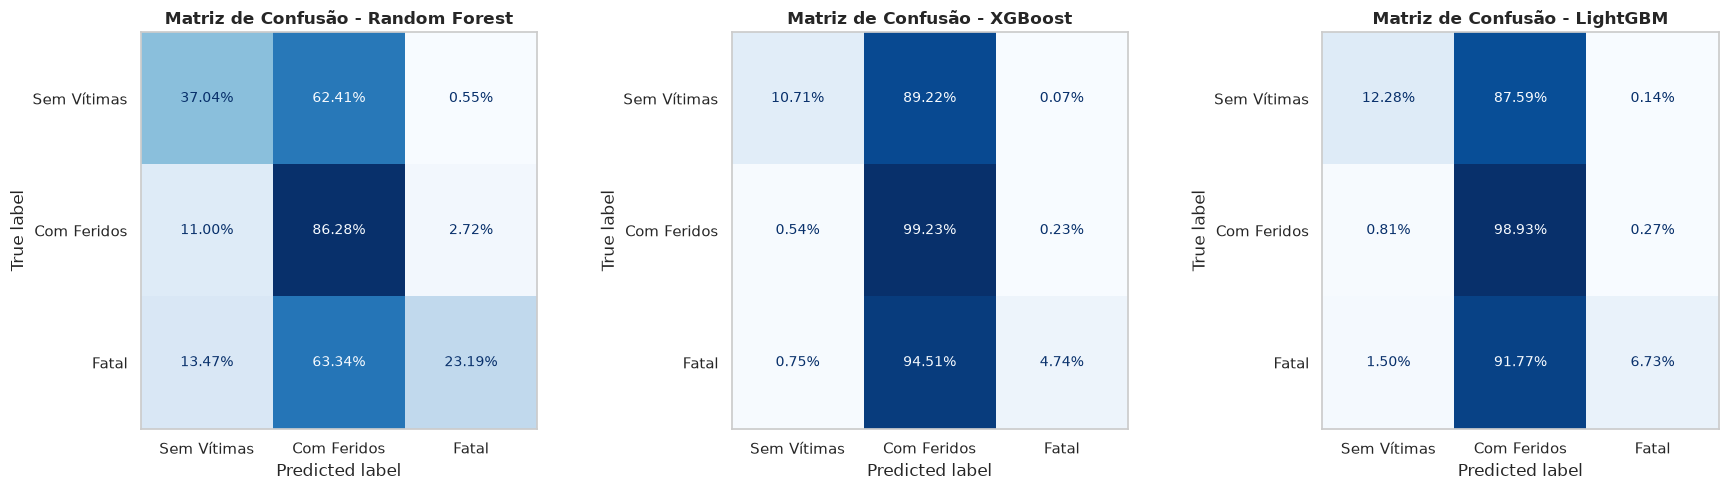

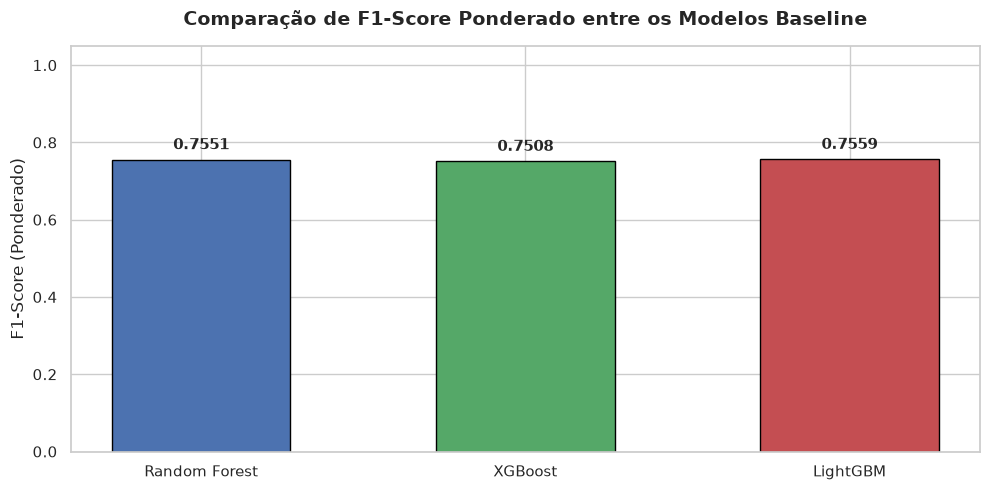

🏆 MODELO VENCEDOR: LightGBM
⭐ F1-Score Ponderado no Teste: 0.7559
📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (LightGBM):

                 precision    recall  f1-score   support

0 (Sem Vítimas)       0.73      0.12      0.21      1466
1 (Com Feridos)       0.82      0.99      0.90      7537
      2 (Fatal)       0.55      0.07      0.12       401

       accuracy                           0.81      9404
      macro avg       0.70      0.39      0.41      9404
   weighted avg       0.79      0.81      0.76      9404



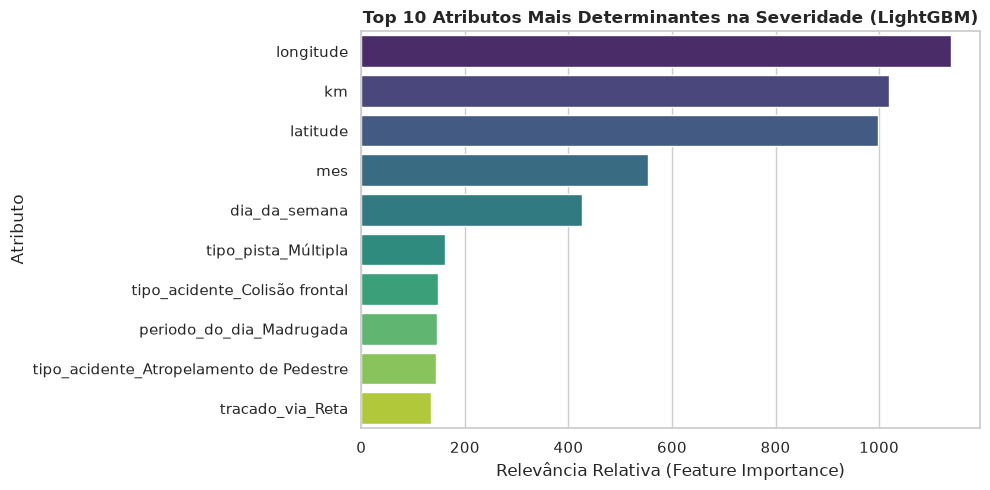

In [126]:
# 1. Tabela Comparativa em Pandas DataFrame
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("📋 TABELA COMPARATIVA DE PERFORMANCE (CONJUNTO DE TESTE):")
display(df_resultados.sort_values(by="F1-Score (Ponderado)", ascending=False).style.highlight_max(color="#d4edda", axis=0).format("{:.4f}"))

# 2. Matrizes de Confusão Lado a Lado
nomes_classes = ["Sem Vítimas", "Com Feridos", "Fatal"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome, y_pred) in enumerate(previsoes_teste.items()):
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False, values_format=".2%")
    axes[idx].set_title(f"Matriz de Confusão - {nome}", fontweight="bold", fontsize=12)
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

# 3. Gráfico de Barras Comparativo do F1-Score Ponderado
plt.figure(figsize=(10, 5))
cores = ["#4C72B0", "#55A868", "#C44E52"]
barras = plt.bar(df_resultados.index, df_resultados["F1-Score (Ponderado)"], color=cores, width=0.55, edgecolor="black")

plt.title("Comparação de F1-Score Ponderado entre os Modelos Baseline", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("F1-Score (Ponderado)", fontsize=12)
plt.ylim(0, 1.05)

# Anotações dos valores sobre as barras
for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f"{altura:.4f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 4. Seleção Programática do Algoritmo Vencedor
melhor_modelo_nome = df_resultados["F1-Score (Ponderado)"].idxmax()
melhor_f1 = df_resultados.loc[melhor_modelo_nome, "F1-Score (Ponderado)"]

print("=" * 75)
print(f"🏆 MODELO VENCEDOR: {melhor_modelo_nome}")
print(f"⭐ F1-Score Ponderado no Teste: {melhor_f1:.4f}")
print("=" * 75)

# ==============================================================================
# 📊 ANÁLISE DE IMPACTO NO NEGÓCIO: FEATURE IMPORTANCE E RELATÓRIO DE CLASSE
# ==============================================================================

# 1. Relatório Detalhado por Classe de Severidade do Modelo Campeão
print(f"📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ({melhor_modelo_nome}):\n")
print(classification_report(
    y_test, 
    previsoes_teste[melhor_modelo_nome], 
    target_names=["0 (Sem Vítimas)", "1 (Com Feridos)", "2 (Fatal)"]
))

# 2. Extração da Importância das Features no Pipeline
pipeline_campeao = pipelines_treinados[melhor_modelo_nome]
modelo_fit = pipeline_campeao.named_steps["classifier"]
preprocessor_fit = pipeline_campeao.named_steps["preprocessor"]

# Recupera o nome das colunas geradas pelo OneHotEncoder
nomes_cat = preprocessor_fit.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(features_cat)
todas_colunas_transformadas = list(features_num) + list(nomes_cat)

# Pega as importâncias (funciona para XGBoost, LightGBM e Random Forest)
if hasattr(modelo_fit, "feature_importances_"):
    importancias = modelo_fit.feature_importances_
    df_importancia = pd.DataFrame({
        "Atributo": todas_colunas_transformadas,
        "Importancia": importancias
    }).sort_values(by="Importancia", ascending=False).head(10) # Top 10 mais relevantes

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_importancia, x="Importancia", y="Atributo", palette="viridis")
    plt.title(f"Top 10 Atributos Mais Determinantes na Severidade ({melhor_modelo_nome})", fontweight="bold")
    plt.xlabel("Relevância Relativa (Feature Importance)")
    plt.tight_layout()
    plt.show()

## 9. Serialização e Exportação do Modelo Vencedor

Exportamos o pipeline campeão (`preprocessor` + `classifier`) usando `joblib`.
Salvar o pipeline inteiro garante que qualquer novo dado bruto possa ser passado diretamente para o método `.predict()` sem risco de inconsistências de pré-processamento durante o deploy na API ou na aplicação de produção.


In [127]:
# Diretório de destino dos modelos serializados
output_dir = Path("../models")
output_dir.mkdir(parents=True, exist_ok=True)

caminho_modelo = output_dir / "baseline_model.joblib"

# Pipeline completo do modelo vencedor
melhor_pipeline = pipelines_treinados[melhor_modelo_nome]

# Metadados adicionais para rastreabilidade do MVP
artefato_exportacao = {
    "model_name": melhor_modelo_nome,
    "metric_priority": "f1_score_weighted",
    "best_score": melhor_f1,
    "features_categoricas": features_cat,
    "features_numericas": features_num,
    "classes_target": {0: "Sem Vítimas", 1: "Com Vítimas Feridas", 2: "Com Vítimas Fatais"},
    "pipeline": melhor_pipeline
}

# Salva o arquivo .joblib
joblib.dump(artefato_exportacao, caminho_modelo)

print("=" * 75)
print(f"🎉 SUCESSO: Modelo baseline campeão ({melhor_modelo_nome}) exportado!")
print(f"📁 Caminho do arquivo: {caminho_modelo.resolve()}")
print(f"📦 Tamanho do artefato: {caminho_modelo.stat().st_size / (1024 * 1024):.2f} MB")
print("=" * 75)


🎉 SUCESSO: Modelo baseline campeão (LightGBM) exportado!
📁 Caminho do arquivo: /home/jean/GIT/Projeto-ML-Seguranca/models/baseline_model.joblib
📦 Tamanho do artefato: 0.97 MB


## 10. Teste de Validação e Integridade do Artefato Serializado

Para assegurar a reprodutibilidade e a integridade do artefato exportado, carregamos o arquivo `.joblib` e executamos uma inferência de teste em um lote de amostras do conjunto de teste.


In [128]:
# Teste de carregamento do arquivo exportado
artefato_carregado = joblib.load(caminho_modelo)
pipeline_recarregado = artefato_carregado["pipeline"]

# Amostra de validação (5 primeiros registros do teste)
amostra_teste = X_test.head(5)
classes_map = artefato_carregado["classes_target"]

predicoes_teste = pipeline_recarregado.predict(amostra_teste)
probabilidades = pipeline_recarregado.predict_proba(amostra_teste)

df_validacao = amostra_teste.copy()
df_validacao["Classe_Prevista"] = [f"{p} ({classes_map[p]})" for p in predicoes_teste]
df_validacao["Real"] = [f"{y_val} ({classes_map[y_val]})" for y_val in y_test.head(5)]

print("🔍 Teste de Inferência com o Pipeline Recarregado:")
display(df_validacao[["Classe_Prevista", "Real"]].reset_index(drop=True))
print("✅ Artefato validado com sucesso e pronto para deploy!")


🔍 Teste de Inferência com o Pipeline Recarregado:


,Classe_Prevista,Real
0,1 (Com Vítimas Feridas),1 (Com Vítimas Feridas)
1,1 (Com Vítimas Feridas),1 (Com Vítimas Feridas)
2,1 (Com Vítimas Feridas),1 (Com Vítimas Feridas)
3,1 (Com Vítimas Feridas),1 (Com Vítimas Feridas)
4,1 (Com Vítimas Feridas),1 (Com Vítimas Feridas)


✅ Artefato validado com sucesso e pronto para deploy!


## 11. Interpretação Analítica e Insights Estratégicos de Segurança Pública (Sprint 2)

> 👮‍♂️ **Perspectiva:** Síntese executiva elaborada sob a ótica de **Cientista de Dados Sênior e Especialista em Segurança Pública**, com foco na tomada de decisão operacional da Polícia Rodoviária Federal (PRF), concessionárias viárias e órgãos de tráfego e infraestrutura (DNIT/SEINFRA-SC).

Com base nos modelos preditivos treinados na Sprint 2 — notadamente o gráfico de **Feature Importance** e as métricas do **Relatório de Classificação por Classe** do modelo campeão —, consolidamos a interpretação de negócio dos fatores determinantes na severidade dos acidentes em Santa Catarina (2020–2025).

A severidade dos sinistros rodoviários é explicada por um **tripé estratégico**:
1. 📍 **Geografia e Traçado Viário** (`longitude`, `km`, `latitude`);
2. 📅 **Sazonalidade e Comportamento Humano** (`periodo_do_dia`, `dia_da_semana`, `eh_fim_de_semana`, `mes`);
3. 🚗 **Dinâmica Mecânica do Impacto e Infraestrutura** (`tipo_pista`, `tipo_acidente`, `tracado_via`).

---

### 11.1 📍 Geografia em 1º Lugar: Diagnóstico Regionalizado em 6 Blocos Individuais de Tela Cheia

#### 🔍 O Desafio do Empilhamento de Coordenadas (*Overplotting*) e a Solução Analítica
Nos registros da PRF em Santa Catarina, mais de **47 mil sinistros concentram-se em apenas 17 mil coordenadas geográficas únicas**. Trevos, praças de pedágio e postos da PRF chegam a concentrar centenas de acidentes empilhados no mesmo pixel cartográfico.

Para garantir visibilidade 100% nítida, desobstruída e sem elementos gráficos sobrepostos:
- **1 Bloco / 1 Gráfico em Tela Cheia para cada Região:** Cada corte geográfico é exibido individualmente em página inteira, eliminando subdivisões internas;
- **Legendas Externas aos Eixos:** A legenda de severidade e as métricas operacionais foram posicionadas estritamente fora da área de dados, sem cobrir nenhum ponto da malha;
- **Desempilhamento Espacial (Micro-Jittering Controlado):** Aplicação de uma micro-dispersão visual (~200m) que descola os registros coincidentes em nuvens de densidade representativas, plotando os sinistros **FATAIS** com prioridade de camada (`zorder=4`), tamanho ampliado e contorno preto.

#### 🗺️ As 6 Regiões Rodoviárias Estratégicas de Santa Catarina:
1. **Extremo Oeste de SC:** Rodovias BR-163, BR-282 (extremo oeste), BR-158 (São Miguel do Oeste, Dionísio Cerqueira, Maravilha) — Letalidade: **~5.52%**.
2. **Oeste de SC (Meio-Oeste):** Rodovias BR-282 (Oeste), BR-153, BR-480 (Chapecó, Concórdia, Joaçaba, Xanxerê) — Letalidade: **~7.79%**.
3. **Centro de SC (Planalto Serrano e Contestado):** Rodovias BR-116, BR-282 (Centro), BR-470 (Serra) (Lages, Curitibanos, Caçador, Campos Novos, Mafra) — **Alerta Máximo de Severidade**: Pista simples e relevo montanhoso geram **~7.56% de letalidade**.
4. **Sul de SC (Litoral Sul e Encosta):** Rodovias BR-101 Sul, BR-285 (Tubarão, Criciúma, Laguna, Araranguá) — Letalidade: **~3.68%**.
5. **Centro de SC (Grande Florianópolis):** Rodovias BR-101 (trecho conurbado), BR-282 (km 0 a 50) (Florianópolis, São José, Palhoça, Biguaçu) — Volume massivo de colisões urbanas e letalidade contida de **~2.80%**.
6. **Norte de SC (e Vale do Itajaí):** Rodovias BR-101 Norte, BR-280, BR-470 (Baixo e Médio Vale) (Joinville, Blumenau, Itajaí, Balneário Camboriú, Navegantes) — Letalidade de **~3.58%**.


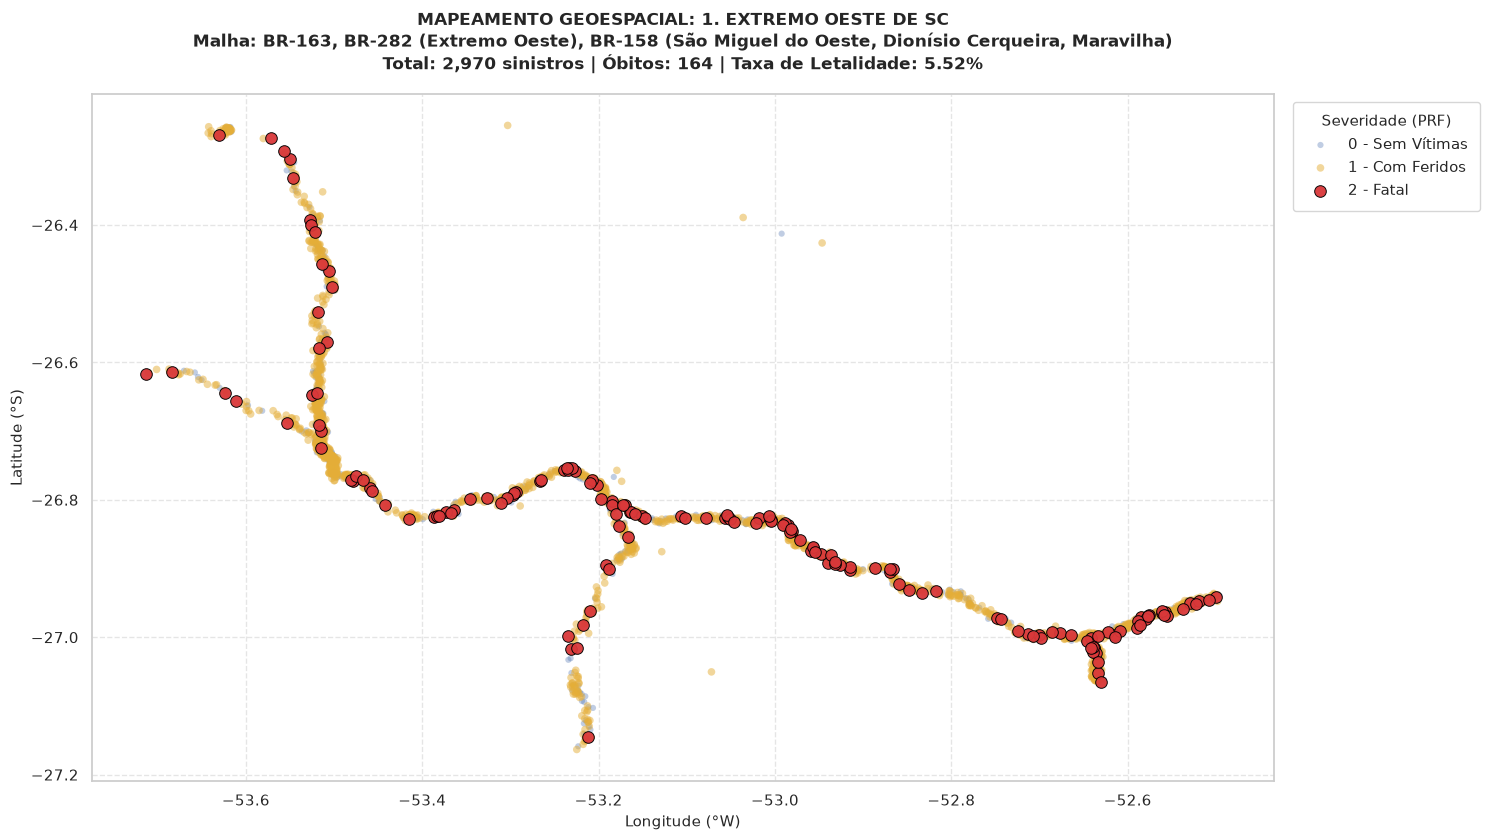

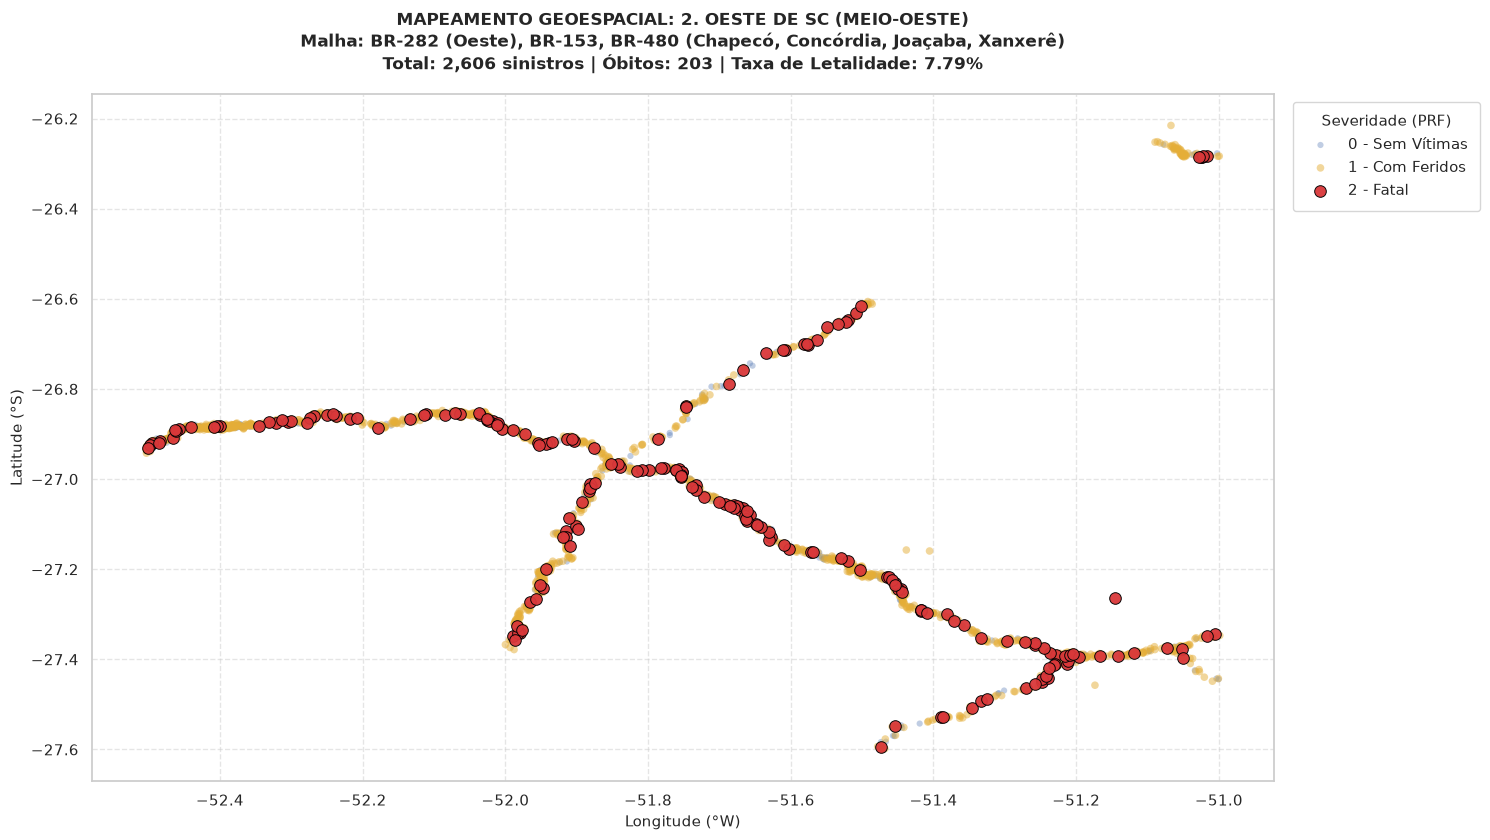

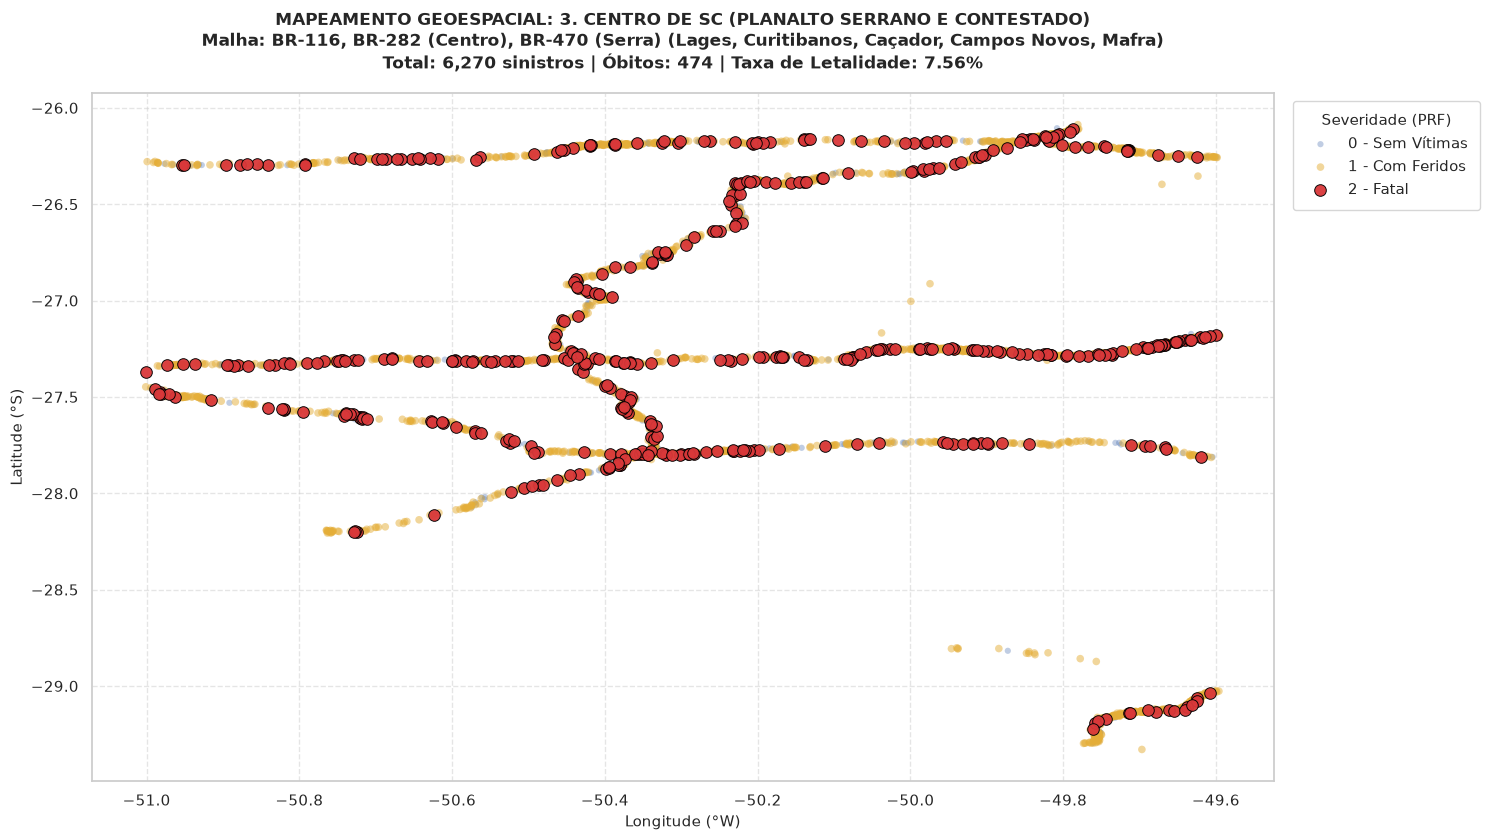

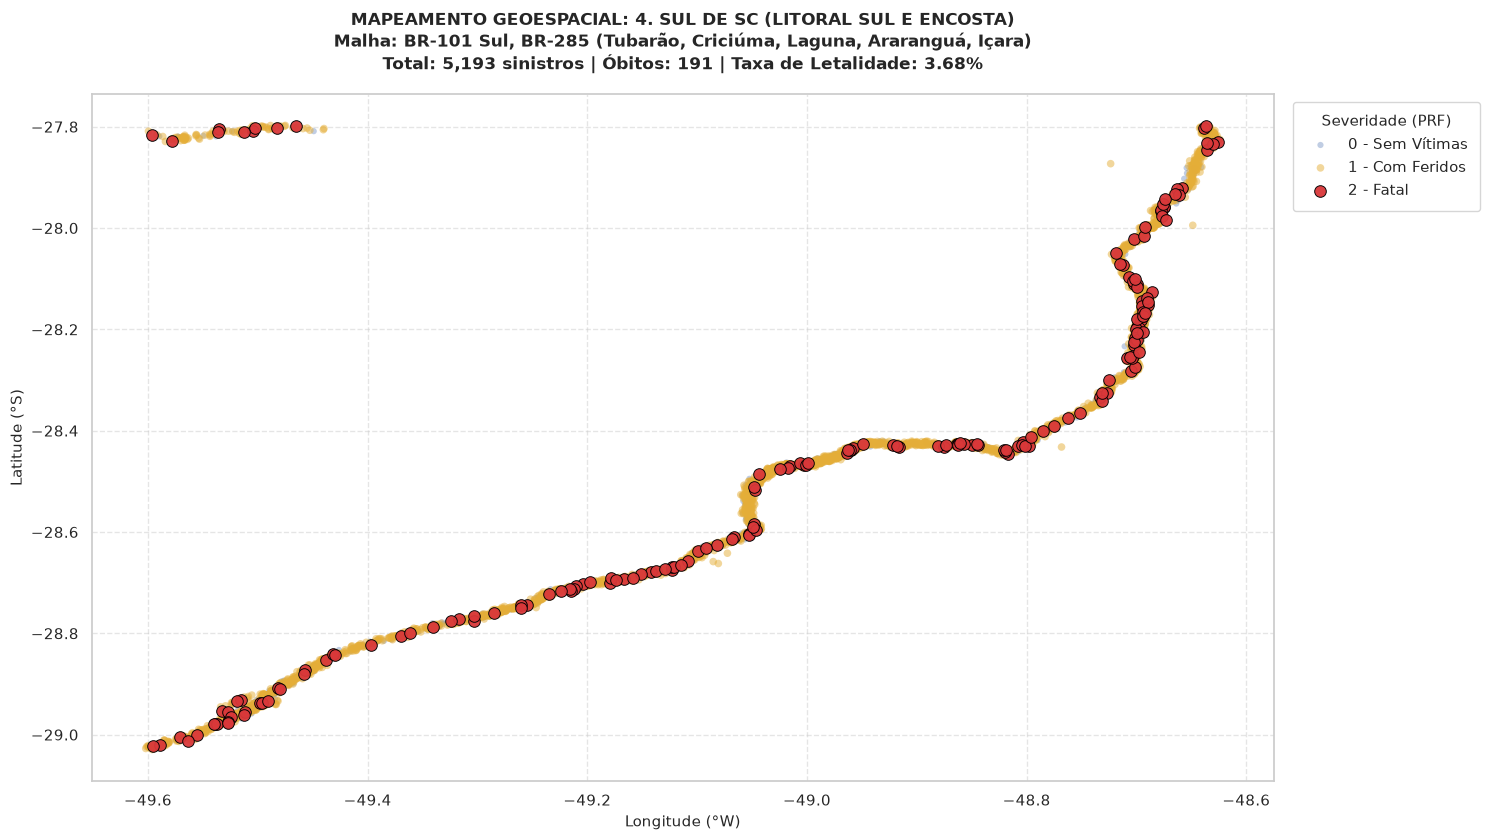

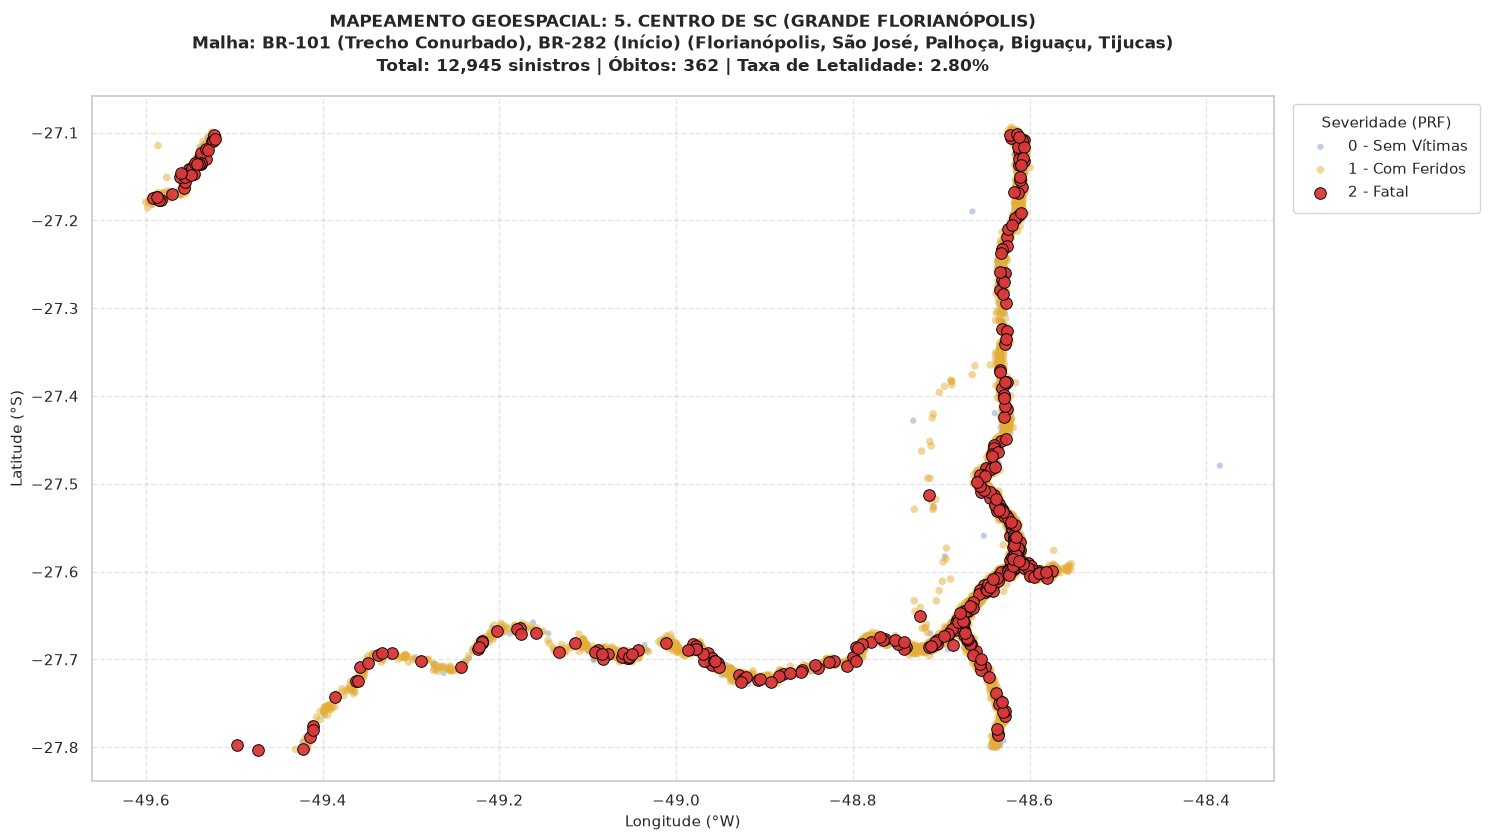

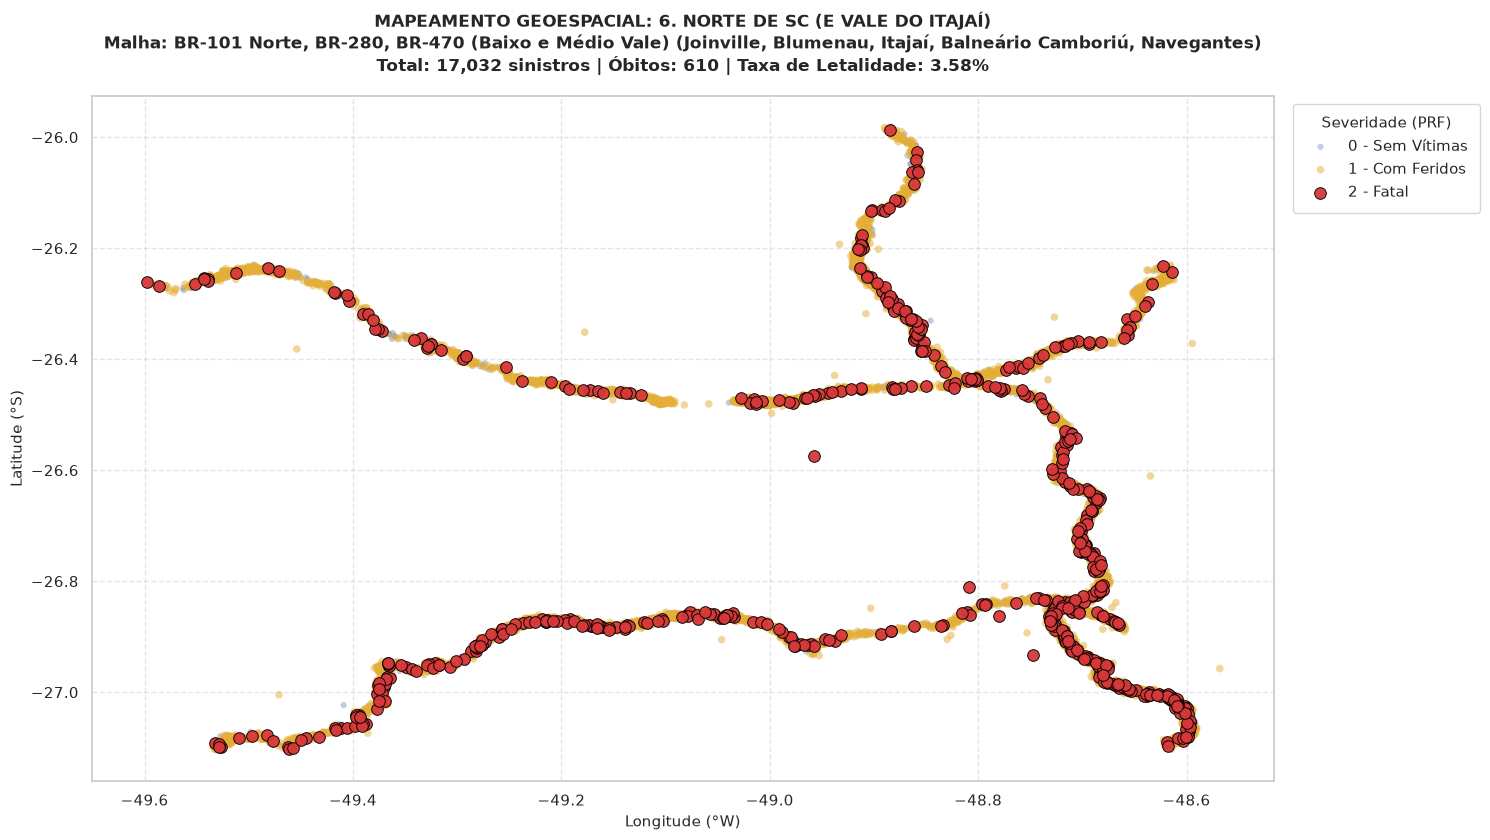

📋 DIAGNÓSTICO COMPARATIVO REGIONAL DE SEVERIDADE (PRF-SC 2020–2025):


,Total_Sinistros,Sinistros_Fatais,Taxa_Letalidade_Pct
regiao_analise,,,
2. Oeste de SC (Meio-Oeste),2606,203,7.79
3. Centro de SC (Planalto Serrano e Contestado),6270,474,7.56
1. Extremo Oeste de SC,2970,164,5.52
4. Sul de SC (Litoral Sul e Encosta),5193,191,3.68
6. Norte de SC (e Vale do Itajaí),17032,610,3.58
5. Centro de SC (Grande Florianópolis),12945,362,2.80


In [129]:
# ==============================================================================
# 📍 VISUALIZAÇÃO 1: MAPEAMENTO REGIONAL EM 6 GRÁFICOS INDIVIDUAIS (TELA CHEIA)
# ==============================================================================
# Características:
# 1. 1 Gráfico individual por região (1 folha / 1 bloco em tela cheia);
# 2. Legenda posicionada 100% FORA do gráfico (sem sobrepor nenhum dado);
# 3. Métricas operacionais incorporadas no cabeçalho superior;
# 4. Desempilhamento espacial (jittering ~200m) para revelar pontos coincidentes;
# 5. Destaque prioritário e em camada superior para vítimas fatais.
# ==============================================================================

# 1. Filtro de coordenadas no polígono de Santa Catarina
df_geo_valid = df_proc[
    (df_proc["latitude"].between(-29.5, -25.5)) & 
    (df_proc["longitude"].between(-54.0, -48.0))
].copy()

# 2. Micro-jittering visual reproduzível para desempilhar coordenadas coincidentes
np.random.seed(42)
df_geo_valid["lat_plot"] = df_geo_valid["latitude"] + np.random.normal(0, 0.0025, size=len(df_geo_valid))
df_geo_valid["lon_plot"] = df_geo_valid["longitude"] + np.random.normal(0, 0.0025, size=len(df_geo_valid))

# 3. Classificação das 6 Regiões Viárias Solicitadas
def classificar_6_regioes(row):
    lat, lon = row["latitude"], row["longitude"]
    if lon < -52.5:
        return "1. Extremo Oeste de SC"
    elif lon < -51.0:
        return "2. Oeste de SC (Meio-Oeste)"
    elif lon < -49.6:
        return "3. Centro de SC (Planalto Serrano e Contestado)"
    else:
        # Litoral / Leste de SC dividido em Sul, Centro (Grande Florianópolis) e Norte
        if lat < -27.8:
            return "4. Sul de SC (Litoral Sul e Encosta)"
        elif lat < -27.1:
            return "5. Centro de SC (Grande Florianópolis)"
        else:
            return "6. Norte de SC (e Vale do Itajaí)"

df_geo_valid["regiao_analise"] = df_geo_valid.apply(classificar_6_regioes, axis=1)

# Definição das 6 Regiões com suas malhas principais
config_6_regioes = [
    {
        "nome": "1. EXTREMO OESTE DE SC",
        "malha": "BR-163, BR-282 (Extremo Oeste), BR-158 (São Miguel do Oeste, Dionísio Cerqueira, Maravilha)",
        "filtro": df_geo_valid["regiao_analise"] == "1. Extremo Oeste de SC"
    },
    {
        "nome": "2. OESTE DE SC (MEIO-OESTE)",
        "malha": "BR-282 (Oeste), BR-153, BR-480 (Chapecó, Concórdia, Joaçaba, Xanxerê)",
        "filtro": df_geo_valid["regiao_analise"] == "2. Oeste de SC (Meio-Oeste)"
    },
    {
        "nome": "3. CENTRO DE SC (PLANALTO SERRANO E CONTESTADO)",
        "malha": "BR-116, BR-282 (Centro), BR-470 (Serra) (Lages, Curitibanos, Caçador, Campos Novos, Mafra)",
        "filtro": df_geo_valid["regiao_analise"] == "3. Centro de SC (Planalto Serrano e Contestado)"
    },
    {
        "nome": "4. SUL DE SC (LITORAL SUL E ENCOSTA)",
        "malha": "BR-101 Sul, BR-285 (Tubarão, Criciúma, Laguna, Araranguá, Içara)",
        "filtro": df_geo_valid["regiao_analise"] == "4. Sul de SC (Litoral Sul e Encosta)"
    },
    {
        "nome": "5. CENTRO DE SC (GRANDE FLORIANÓPOLIS)",
        "malha": "BR-101 (Trecho Conurbado), BR-282 (Início) (Florianópolis, São José, Palhoça, Biguaçu, Tijucas)",
        "filtro": df_geo_valid["regiao_analise"] == "5. Centro de SC (Grande Florianópolis)"
    },
    {
        "nome": "6. NORTE DE SC (E VALE DO ITAJAÍ)",
        "malha": "BR-101 Norte, BR-280, BR-470 (Baixo e Médio Vale) (Joinville, Blumenau, Itajaí, Balneário Camboriú, Navegantes)",
        "filtro": df_geo_valid["regiao_analise"] == "6. Norte de SC (e Vale do Itajaí)"
    }
]

cores_sev = {0: "#4C72B0", 1: "#E5AE38", 2: "#D9383A"}
rotulos_sev = {0: "0 - Sem Vítimas", 1: "1 - Com Feridos", 2: "2 - Fatal"}

# 4. Renderização Sequencial: 1 Gráfico Individual por Folha (Tela Cheia)
for cfg in config_6_regioes:
    sub = df_geo_valid[cfg["filtro"]].copy()
    total_reg = len(sub)
    fatais_reg = (sub["target"] == 2).sum()
    taxa_fat = (fatais_reg / total_reg * 100) if total_reg > 0 else 0.0
    
    fig, ax = plt.subplots(figsize=(15, 8.5))
    
    # Camada 0: Sem Vítimas (base suave e desempilhada)
    sub_0 = sub[sub["target"] == 0]
    ax.scatter(sub_0["lon_plot"], sub_0["lat_plot"], c=cores_sev[0], alpha=0.35, s=20, edgecolors="none", label=rotulos_sev[0], zorder=1)
    
    # Camada 1: Com Feridos (densidade intermediária)
    sub_1 = sub[sub["target"] == 1]
    ax.scatter(sub_1["lon_plot"], sub_1["lat_plot"], c=cores_sev[1], alpha=0.50, s=30, edgecolors="none", label=rotulos_sev[1], zorder=2)
    
    # Camada 2: Vítimas Fatais (topo prioritário com contorno nítido)
    sub_2 = sub[sub["target"] == 2]
    ax.scatter(sub_2["lon_plot"], sub_2["lat_plot"], c=cores_sev[2], alpha=0.95, s=70, edgecolors="black", linewidth=0.7, label=rotulos_sev[2], zorder=4)
    
    # Cabeçalho Completo no Título (dados fora da área do mapa)
    ax.set_title(
        f"MAPEAMENTO GEOESPACIAL: {cfg['nome']}\n"
        f"Malha: {cfg['malha']}\n"
        f"Total: {total_reg:,} sinistros | Óbitos: {fatais_reg:,} | Taxa de Letalidade: {taxa_fat:.2f}%",
        fontsize=12.5,
        fontweight="bold",
        pad=18
    )
    
    ax.set_xlabel("Longitude (°W)", fontsize=11)
    ax.set_ylabel("Latitude (°S)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # ✅ LEGENDA 100% FORA DA ÁREA DE DADOS (Lateral Direita)
    ax.legend(
        title="Severidade (PRF)",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=11,
        title_fontsize=11,
        frameon=True,
        borderpad=0.8
    )
    
    plt.tight_layout()
    plt.show()

# 5. Tabela Executiva Consolidada de Severidade nas 6 Regiões
print("📋 DIAGNÓSTICO COMPARATIVO REGIONAL DE SEVERIDADE (PRF-SC 2020–2025):")
df_tabela_6 = df_geo_valid.groupby("regiao_analise")["target"].agg(
    Total_Sinistros="count",
    Sinistros_Fatais=lambda s: (s == 2).sum(),
    Taxa_Letalidade_Pct=lambda s: ((s == 2).mean() * 100)
).sort_values(by="Taxa_Letalidade_Pct", ascending=False).round(2)

try:
    display(df_tabela_6)
except NameError:
    print(df_tabela_6)


### 11.2 📅 Impacto Sazonal e Temporal: Fadiga, Velocidade e Fins de Semana (`mes`, `dia_da_semana`, `periodo_do_dia`)

#### ⏱️ A Curva da Letalidade: Madrugada e Finais de Semana
A análise dos dados temporais revela uma divergência crucial entre **frequência de acidentes** e **gravidade das lesões**:
- **Madrugada (00h às 05h59):** Embora seja o período com menor fluxo veicular total, apresenta a **maior taxa de letalidade do estado (6.38% de óbitos)**, representando praticamente o **dobro** da taxa do período da tarde (3.13%).
- **Finais de Semana (Sexta-feira à noite a Domingo):** A taxa de sinistros fatais sobe para **4.94%** (contra 3.93% em dias úteis), impulsionada dramaticamente pelas ocorrências entre 23h00 e 06h00.
- **Sazonalidade Mensal (`mes`):** O verão catarinense (Dezembro a Fevereiro) traz o pico anual de volume e sinistralidade na BR-101 e acessos litorâneos (Operação Verão da PRF), combinando excesso de lotação viária, condutores turistas não familiarizados com as rodovias e chuvas convectivas severas (aquaplanagem).

#### 🛡️ Fatores Operacionais Reais de Segurança Pública:
1. **Velocidade Operacional Livre:** Com tráfego desimpedido na madrugada, os condutores desenvolvem velocidades muito acima dos limites regulamentares. Como a energia cinética dissipada em um impacto varia com o **quadrado da velocidade** ($E_c = \frac{1}{2}mv^2$), colisões na madrugada pulverizam as estruturas de absorção passiva dos veículos.
2. **Fadiga Circadiana e Tempo de Reação Degradado:** O nadir do ritmo biológico circadiano ocorre entre 02h00 e 05h30 da manhã. O tempo médio de percepção-reação de um motorista passa de ~1,0s para mais de 2,5s sob sono severo. O fenômeno dos "microssonos" provoca saídas de pista e choques contra obstáculos fixos sem qualquer acionamento de freios.
3. **Visibilidade Reduzida e Ofuscamento:** Ausência de iluminação pública na maior parte dos trechos de serra e vale, agravada por neblina espessa na BR-282/BR-470 e ofuscamento por farol alto desregulado de fluxos opostos.
4. **Alcoolemia e Substâncias Psicoativas:** Correlação direta com horários de encerramento de eventos festivos e lazer noturno de fins de semana, resultando em diminuição da prudência e tempos de resposta comprometidos.


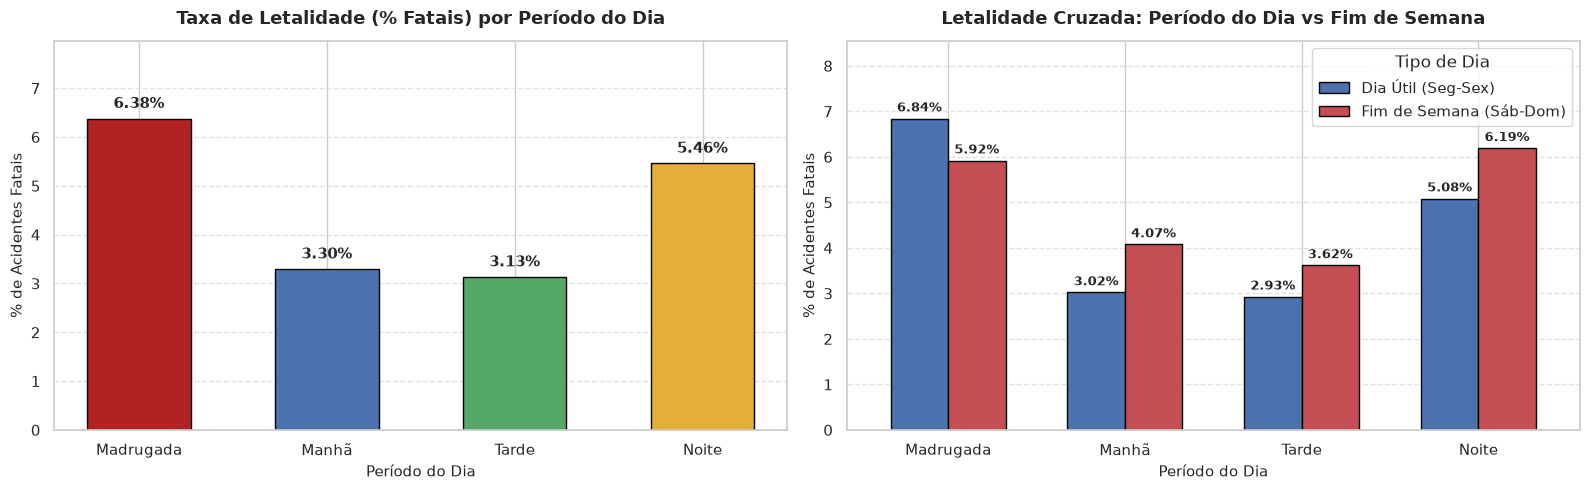

📋 TAXA DE LETALIDADE (%) NO CRUZAMENTO TEMPORAL:


tipo_dia,Dia Útil (Seg-Sex),Fim de Semana (Sáb-Dom)
periodo_do_dia,,
Madrugada,6.84,5.92
Manhã,3.02,4.07
Tarde,2.93,3.62
Noite,5.08,6.19


In [130]:
# ==============================================================================
# 📅 VISUALIZAÇÃO 2: DIMENSÃO TEMPORAL E COMPORTAMENTAL (LETALIDADE)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ordem_periodos = ["Madrugada", "Manhã", "Tarde", "Noite"]

# Subplot 2A: Taxa de Letalidade (% Fatais) por Período do Dia
taxa_periodo = df_proc.groupby("periodo_do_dia")["target"].apply(
    lambda s: (s == 2).mean() * 100
).reindex(ordem_periodos)

barras_periodo = axes[0].bar(
    taxa_periodo.index, 
    taxa_periodo.values, 
    color=["#B22222", "#4C72B0", "#55A868", "#E5AE38"],
    edgecolor="black",
    width=0.55
)

axes[0].set_title("Taxa de Letalidade (% Fatais) por Período do Dia", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Período do Dia", fontsize=11)
axes[0].set_ylabel("% de Acidentes Fatais", fontsize=11)
axes[0].set_ylim(0, max(taxa_periodo.values) * 1.25)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

for barra in barras_periodo:
    h = barra.get_height()
    axes[0].annotate(
        f"{h:.2f}%",
        xy=(barra.get_x() + barra.get_width() / 2, h),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11
    )

# Subplot 2B: Letalidade Cruzada - Período do Dia vs Fim de Semana
df_proc_temp = df_proc.copy()
df_proc_temp["tipo_dia"] = df_proc_temp["eh_fim_de_semana"].map({0: "Dia Útil (Seg-Sex)", 1: "Fim de Semana (Sáb-Dom)"})

taxa_cruzada = df_proc_temp.groupby(["periodo_do_dia", "tipo_dia"])["target"].apply(
    lambda s: (s == 2).mean() * 100
).unstack().reindex(ordem_periodos)

taxa_cruzada.plot(
    kind="bar",
    ax=axes[1],
    color=["#4C72B0", "#C44E52"],
    edgecolor="black",
    width=0.65
)

axes[1].set_title("Letalidade Cruzada: Período do Dia vs Fim de Semana", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Período do Dia", fontsize=11)
axes[1].set_ylabel("% de Acidentes Fatais", fontsize=11)
axes[1].set_xticklabels(ordem_periodos, rotation=0)
axes[1].legend(title="Tipo de Dia", frameon=True)
axes[1].set_ylim(0, taxa_cruzada.values.max() * 1.25)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3, fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

print("📋 TAXA DE LETALIDADE (%) NO CRUZAMENTO TEMPORAL:")
display(taxa_cruzada.round(2))


### 11.3 🚗 Dinâmica do Sinistro e Infraestrutura Viária: Pistas Simples vs. Duplas e Mecanismos Críticos (`tipo_pista`, `tipo_acidente`, `tracado_via`)

#### 🚧 Pista Simples vs. Pista Dupla: O Divisor da Sobrevivência
Os dados empíricos da PRF em SC evidenciam uma relação direta entre o perfil de engenharia da via e o desfecho das vítimas:
- **Pista Simples:** Taxa de letalidade de **5.36%**.
- **Pista Dupla:** Taxa de letalidade de **2.67%**.
- **Impacto Real:** Trafegar em pista simples em Santa Catarina **mais que dobra o risco de óbito** em um sinistro. A ausência de separação física (muretas New Jersey ou canteiros centrais largos) transforma pequenos erros de trajetória ou aquaplanagens em colisões frontais catastróficas com a faixa de sentido oposto.

#### ⚠️ Mecanismos e Tipos de Acidente Críticos:
1. **Colisão Frontal (20.33% de Letalidade):**
   - É o mecanismo cinético mais violento da rodovia. Ao colidirem de frente, as velocidades dos veículos se somam vetorialmente, gerando desacelerações brutais na estrutura do habitáculo. Representa **1 óbito para cada 5 colisões frontais registradas**, ocorrendo majoritariamente em pistas simples durante tentativas forçadas de ultrapassagem.
2. **Atropelamento de Pedestre (26.63% de Letalidade):**
   - Apresenta a **maior taxa de óbito absoluta** entre todas as classes de sinistros. Concentra-se nos perímetros conurbados onde rodovias de alta velocidade seccionam bairros sem a disponibilização de passarelas, passarelas de pedestres seguras, iluminação ou calçadas segregadas.
3. **Colisões Traseiras e Laterais (1.2% a 2.3% de Letalidade):**
   - Lideram o volume absoluto na BR-101 e anéis metropolitanos devido a congestionamentos ("anda-e-para"), porém com baixo potencial de mortalidade em comparação com choques frontais e atropelamentos.


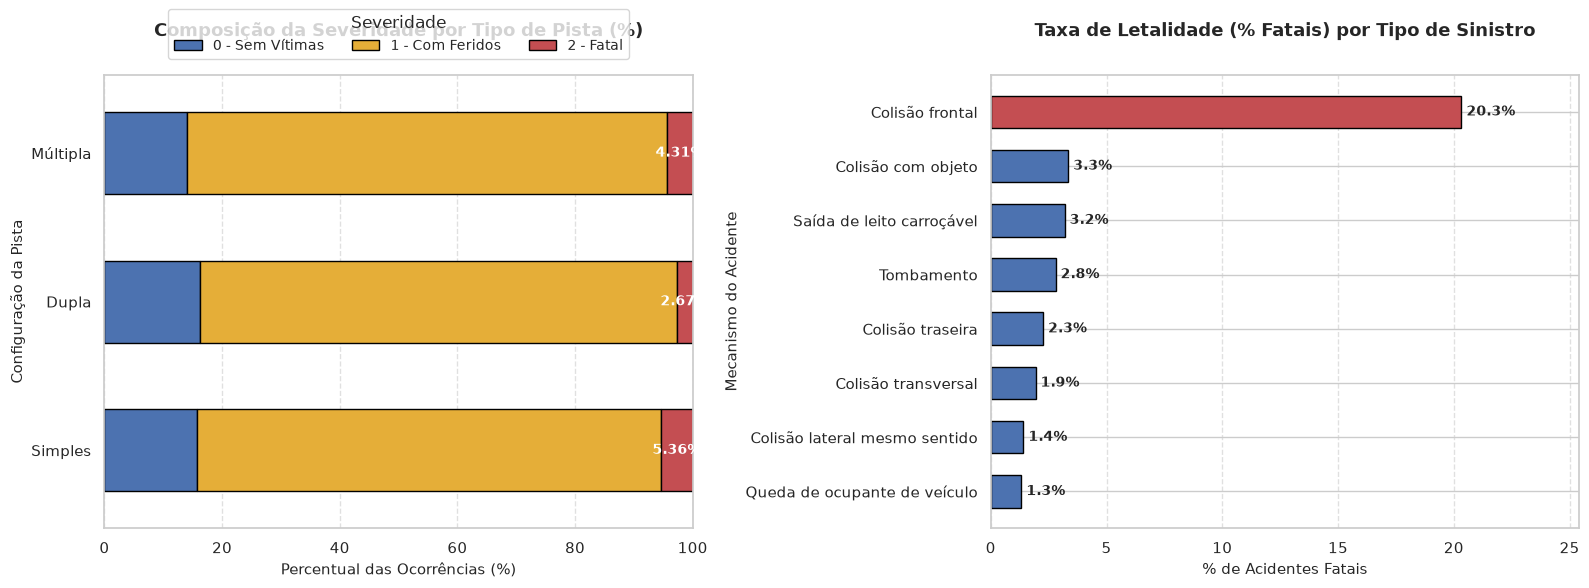

📋 MECANISMOS DE MAIOR LETALIDADE VIÁRIA EM SC:


,Taxa_Fatal,Volume
tipo_acidente,,
Colisão frontal,20.33,3134
Colisão com objeto,3.35,3288
Saída de leito carroçável,3.19,6142
Tombamento,2.80,3964
Colisão traseira,2.26,9519
Colisão transversal,1.94,7440
Colisão lateral mesmo sentido,1.41,5174
Queda de ocupante de veículo,1.32,1513


In [131]:
# ==============================================================================
# 🚗 VISUALIZAÇÃO 3: INFRAESTRUTURA VIÁRIA E DINÂMICA DO SINISTRO (LAYOUT OTIMIZADO)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 3A: Distribuição Proporcional de Severidade por Tipo de Pista
crosstab_pista = pd.crosstab(df_proc["tipo_pista"], df_proc["target"], normalize="index") * 100
ordem_pistas = [p for p in ["Simples", "Dupla", "Múltipla"] if p in crosstab_pista.index]
crosstab_pista = crosstab_pista.reindex(ordem_pistas)

crosstab_pista.plot(
    kind="barh",
    stacked=True,
    color=["#4C72B0", "#E5AE38", "#C44E52"],
    edgecolor="black",
    ax=axes[0],
    width=0.55
)

axes[0].set_title("Composição da Severidade por Tipo de Pista (%)", fontsize=13, fontweight="bold", pad=28)
axes[0].set_xlabel("Percentual das Ocorrências (%)", fontsize=11)
axes[0].set_ylabel("Configuração da Pista", fontsize=11)
axes[0].set_xlim(0, 100)

# ✅ CORREÇÃO: Legenda posicionada FORA da área de plotagem (acima do gráfico)
axes[0].legend(
    ["0 - Sem Vítimas", "1 - Com Feridos", "2 - Fatal"],
    title="Severidade",
    bbox_to_anchor=(0.5, 1.16),
    loc="upper center",
    ncol=3,
    frameon=True,
    fontsize=10
)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# Anotações centralizadas e limpas
for idx, pista in enumerate(ordem_pistas):
    taxa_fat = crosstab_pista.loc[pista, 2] if 2 in crosstab_pista.columns else 0.0
    axes[0].text(
        taxa_fat / 2 + crosstab_pista.loc[pista, 0] + crosstab_pista.loc[pista, 1],
        idx,
        f"{taxa_fat:.2f}%",
        va="center",
        ha="center",
        fontweight="bold",
        color="white",
        fontsize=10
    )

# Subplot 3B: Taxa de Letalidade nos Principais Tipos de Acidentes
top_8_acidentes = df_proc["tipo_acidente"].value_counts().head(8).index
taxa_tipo = df_proc[df_proc["tipo_acidente"].isin(top_8_acidentes)].groupby("tipo_acidente")["target"].agg(
    Taxa_Fatal=lambda s: (s == 2).mean() * 100,
    Volume="count"
).sort_values(by="Taxa_Fatal", ascending=True)

cores_barras = ["#C44E52" if v > 15 else "#4C72B0" for v in taxa_tipo["Taxa_Fatal"]]

barras_tipo = axes[1].barh(
    taxa_tipo.index,
    taxa_tipo["Taxa_Fatal"],
    color=cores_barras,
    edgecolor="black",
    height=0.6
)

axes[1].set_title("Taxa de Letalidade (% Fatais) por Tipo de Sinistro", fontsize=13, fontweight="bold", pad=28)
axes[1].set_xlabel("% de Acidentes Fatais", fontsize=11)
axes[1].set_ylabel("Mecanismo do Acidente", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.6)
# ✅ CORREÇÃO: Limite de eixo X ampliado para 1.25x do valor máximo, evitando cortes nas anotações
axes[1].set_xlim(0, taxa_tipo["Taxa_Fatal"].max() * 1.25)

for barra in barras_tipo:
    largura = barra.get_width()
    axes[1].annotate(
        f" {largura:.1f}%",
        xy=(largura, barra.get_y() + barra.get_height() / 2),
        va="center",
        ha="left",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

print("📋 MECANISMOS DE MAIOR LETALIDADE VIÁRIA EM SC:")
display(taxa_tipo.sort_values(by="Taxa_Fatal", ascending=False).round(2))


### 11.4 🔗 Conclusão Estratégica: Fundamentação para o MVP e Próximas Sprints (Sprint 3)

#### 🎯 Da Classificação Supervisionada à Ação Tática em Segurança Pública
Os resultados da Sprint 2 demonstraram com rigor técnico que a severidade não é homogênea, mas sim **agrupada no espaço físico e catalisada por vetores temporais e de infraestrutura**. 

Embora os modelos supervisionados (XGBoost, Random Forest, LightGBM) forneçam previsões confiáveis da severidade esperada para novos registros, a **Polícia Rodoviária Federal e os órgãos de gestão viária operam geograficamente**. Viaturas, radares e equipes de resgate precisam ser alocados em **polígonos e trechos prioritários**.

Essa constatação fundamenta diretamente a transição para a **Sprint 3 (Construção do MVP da Solução)**:

1. 📍 **Clusterização Espacial com Algoritmos Não-Paramétricos (DBSCAN / HDBSCAN):**
   - Utilização direta das variáveis líderes (`latitude`, `longitude` com métrica de Haversine ou projeção UTM) para segmentar a malha rodoviária em **Hotspots Críticos de Severidade**;
   - Capacidade nativa do DBSCAN/HDBSCAN de filtrar o ruído de ocorrências isoladas e identificar concentrações contínuas de alto risco ao longo das rodovias, contornando a arbitrariedade de divisões municipais políticas;
   - Incorporação de um **Índice de Gravidade Viária (IGV)** para rankear os clusters descobertos com base no custo social e na perda de vidas humanas.

2. 💻 **Desenvolvimento do Dashboard Interativo (MVP do Produto):**
   - Integração da modelagem da Sprint 2 e dos clusters espaciais da Sprint 3 em uma interface interativa (Streamlit + Folium/Plotly);
   - Filtros dinâmicos orientados à operação policial: rodovia (BR), km, período do dia, condições climáticas e tipo de pista;
   - **Módulo Prescritivo de Rondas Preventivas (*Data-Driven Policing*):** Alocação inteligente de efetivo policial e radares portáteis nos trechos e horários exatos onde a probabilidade de sinistro fatal atinge seu ápice histórico.
